# COMP4037 Research Methods – Coursework 2: Data Visualization
## Emergency Hospital Admissions Streamgraph (1998/99 – 2023/24)

**Research Question:** What changes have occurred in terms of the breakdown of emergency hospital admissions for various ICD-10 diagnoses over the last quarter-century, and which categories of diagnoses are responsible for the rise in numbers?

**Visualization Type:** Streamgraph (ThemeRiver)  
**Software Used:** Python 3 (Matplotlib, SciPy, Pandas)  
**Dataset Used:** NHS Hospital Episode Statistics (HES), England


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import make_interp_spline
import os
import re
import warnings
warnings.filterwarnings('ignore')

## 1. Define ICD-10 Chapters Mappings

ICD-10 categorisation codes diagnoses in 21 different chapters. Every set of summary-level code numbers
(e.g. A00-A09) in the NHS Hospital Episode Statistics data corresponds to one chapter.
We provide the definition below to allow us to aggregate summary-level data to chapters.

**Remark:** Chapter XX (External causes, V01-Y98) is not found in the primary diagnosis summaries
and will be thus ignored.


In [2]:
# ICD-10 Chapter definitions: chapter number -> (start_code, end_code, description)
ICD10_CHAPTERS = {
    'I':     ('A00', 'B99', 'Infectious & parasitic diseases'),
    'II':    ('C00', 'D48', 'Neoplasms'),
    'III':   ('D50', 'D89', 'Blood & immune disorders'),
    'IV':    ('E00', 'E90', 'Endocrine, nutritional & metabolic'),
    'V':     ('F00', 'F99', 'Mental & behavioural disorders'),
    'VI':    ('G00', 'G99', 'Nervous system diseases'),
    'VII':   ('H00', 'H59', 'Eye & adnexa diseases'),
    'VIII':  ('H60', 'H95', 'Ear & mastoid diseases'),
    'IX':    ('I00', 'I99', 'Circulatory system diseases'),
    'X':     ('J00', 'J99', 'Respiratory system diseases'),
    'XI':    ('K00', 'K93', 'Digestive system diseases'),
    'XII':   ('L00', 'L99', 'Skin & subcutaneous tissue'),
    'XIII':  ('M00', 'M99', 'Musculoskeletal & connective tissue'),
    'XIV':   ('N00', 'N99', 'Genitourinary system diseases'),
    'XV':    ('O00', 'O99', 'Pregnancy & childbirth'),
    'XVI':   ('P00', 'P96', 'Perinatal conditions'),
    'XVII':  ('Q00', 'Q99', 'Congenital malformations'),
    'XVIII': ('R00', 'R99', 'Symptoms & abnormal findings'),
    'XIX':   ('S00', 'T98', 'Injury & poisoning'),
    'XXI':   ('Z00', 'Z99', 'Health services contacts'),
}

def code_to_chapter(code_str):
    """Map a summary code like 'A00-A09' or 'A00' to its ICD-10 chapter number."""
    match = re.match(r'([A-Z]\d{2})', str(code_str).strip())
    if not match:
        return None
    letter = match.group(1)[0]
    num = int(match.group(1)[1:])
    
    for ch_num, (ch_start, ch_end, _) in ICD10_CHAPTERS.items():
        s_letter, s_num = ch_start[0], int(ch_start[1:])
        e_letter, e_num = ch_end[0], int(ch_end[1:])
        if s_letter == e_letter:
            if letter == s_letter and s_num <= num <= e_num:
                return ch_num
        else:
            if (letter == s_letter and num >= s_num) or \
               (letter == e_letter and num <= e_num) or \
               (s_letter < letter < e_letter):
                return ch_num
    return None

# Quick test
assert code_to_chapter('A00-A09') == 'I'
assert code_to_chapter('C15-C26') == 'II'
assert code_to_chapter('F00-F09') == 'V'
assert code_to_chapter('R00-R09') == 'XVIII'
print("ICD-10 chapter mapping verified.")

ICD-10 chapter mapping verified.


## 2. Helper Functions for Parsing the Spreadsheets

The NHS HES spreadsheets span 26 years and use different formats:
- **1998–2011:** `.xls` files in year-named subfolders, with varying header row positions
- **2012–2023:** `.xlsx` files in the root folder, with code and description in separate columns

The following functions account for these differences by dynamically finding the column header "Emergency," 
and retrieving the ICD summary code from the first column.


In [3]:
def find_emergency_col(df, max_rows=30):
    """Search the first `max_rows` rows for a cell containing 'Emergency'.
    Returns (header_row_index, emergency_column_index) or (None, None)."""
    for i in range(min(max_rows, len(df))):
        for j in range(df.shape[1]):
            if 'Emergency' in str(df.iloc[i, j]):
                return i, j
    return None, None

def parse_code_from_cell(val):
    """Extract an ICD code like 'A00-A09' or just 'A00' from a cell 
    that might contain the code concatenated with a description."""
    match = re.match(r'([A-Z]\d{2}[-–][A-Z]\d{2})', str(val).strip())
    if match:
        return match.group(1).replace('\u2013', '-')  # normalise en-dash
    match = re.match(r'([A-Z]\d{2})', str(val).strip())
    if match:
        return match.group(1)
    return None

def safe_float(val):
    """Convert a cell value to float, handling commas, dashes, asterisks, 
    and other non-numeric markers found in the NHS data."""
    try:
        s = str(val).replace(',', '').replace('*', '0').replace(' ', '')
        if s in ('nan', '', '..', '-'):
            return 0
        return float(s)
    except (ValueError, TypeError):
        return 0

print("Helper functions defined.")

Helper functions defined.


### 3. Importing and Merging Data for All 26 Years

We go through each file, find the summary sheet along with the Emergency admissions column,
extract the summary level rows, assign them to the appropriate ICD-10 chapter, and record the 
number of emergency admissions.

**Note:** We only use the Primary Diagnosis Summary sheets and not the 3-character or 4-character
detail sheets since these have the summary code ranges which can be easily mapped to ICD-10 chapters.

In [ ]:
%pip install xlrd
%pip install openpyxl
# ---- CONFIGURE THIS PATH to where you extracted the NHS data ----
BASE_DIR = "NHS Hospital Admissions"

all_data = []

# =====================================================================
# PART A: Year-folder .xls files (1998–2011)
# =====================================================================
for year in range(1998, 2012):
    year_dir = os.path.join(BASE_DIR, str(year))
    if not os.path.isdir(year_dir):
        print(f"  {year}: directory not found, skipping")
        continue
    
    # Find the summary file in the year folder
    summary_file = None
    for fn in os.listdir(year_dir):
        if fn.endswith('.xls'):
            if 'sum' in fn.lower():
                summary_file = os.path.join(year_dir, fn)
                break
            # 2007 uses a different naming convention (no 'sum' in filename)
            if year == 2007 and '3cha' not in fn and '4cha' not in fn:
                summary_file = os.path.join(year_dir, fn)
    
    if not summary_file:
        print(f"  {year}: no summary file found")
        continue
    
    df = pd.read_excel(summary_file, sheet_name=0, header=None)
    header_row, emergency_col = find_emergency_col(df)
    
    if header_row is None:
        print(f"  {year}: could not locate Emergency column")
        continue
    
    count = 0
    for i in range(header_row + 1, len(df)):
        cell0 = str(df.iloc[i, 0]).strip()
        if cell0 in ('nan', '') or 'Total' in cell0:
            continue
        
        code = parse_code_from_cell(cell0)
        if not code:
            continue
        chapter = code_to_chapter(code)
        if chapter is None:
            continue
        
        all_data.append({
            'year': year,
            'chapter': chapter,
            'chapter_name': ICD10_CHAPTERS[chapter][2],
            'emergency': safe_float(df.iloc[i, emergency_col])
        })
        count += 1
    
    print(f"  {year}: {count} rows extracted (header row={header_row}, emergency col={emergency_col})")

# =====================================================================
# PART B: Root-level .xlsx files (2012–2023)
# =====================================================================
xlsx_files = sorted([f for f in os.listdir(BASE_DIR) if f.endswith('.xlsx')])

for fn in xlsx_files:
    match = re.search(r'(\d{4})-(\d{2})', fn)
    if not match:
        continue
    year = int(match.group(1))
    
    filepath = os.path.join(BASE_DIR, fn)
    xls = pd.ExcelFile(filepath)
    
    # Find the summary sheet (name varies across years)
    summary_sheet = None
    for s in xls.sheet_names:
        if 'ummary' in s.lower():
            summary_sheet = s
            break
    
    if not summary_sheet:
        print(f"  {year}: no summary sheet found in {xls.sheet_names}")
        continue
    
    df = pd.read_excel(filepath, sheet_name=summary_sheet, header=None)
    header_row, emergency_col = find_emergency_col(df)
    
    if header_row is None:
        print(f"  {year}: could not locate Emergency column")
        continue
    
    count = 0
    for i in range(header_row + 1, len(df)):
        cell0 = str(df.iloc[i, 0]).strip()
        if cell0 in ('nan', '') or 'Total' in cell0:
            continue
        
        code = parse_code_from_cell(cell0)
        if not code:
            continue
        chapter = code_to_chapter(code)
        if chapter is None:
            continue
        
        all_data.append({
            'year': year,
            'chapter': chapter,
            'chapter_name': ICD10_CHAPTERS[chapter][2],
            'emergency': safe_float(df.iloc[i, emergency_col])
        })
        count += 1
    
    print(f"  {year}: {count} rows extracted (header row={header_row}, emergency col={emergency_col})")

print(f"\nTotal raw rows collected: {len(all_data)}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  1998: 147 rows extracted (header row=3, emergency col=4)
  1999: 147 rows extracted (header row=3, emergency col=4)
  2000: 147 rows extracted (header row=3, emergency col=4)
  2001: 147 rows extracted (header row=3, emergency col=4)
  2002: 147 rows extracted (header row=3, emergency col=4)
  2003: 147 rows extracted (header row=3, emergency col=4)
  2004: 147 rows extracted (header row=3, emergency col=4)
  2005: 147 rows extracted (header row=10, emergency col=4)
  2006: 147 rows extracted (header row=10, emergency col=4)
  2007: 147 rows extracted (header row=15, emergency col=4)
  2008: 137 rows extracted (header row=15, emergency col=4)
  2009: 140 rows extracted (header row=15, emergency col=4)
  2010: 140 rows extracted (header row=15, emergency col=4)
  2011: 140 rows extracted (header row=15, emergency col=4)
  2012: 142 rows extracted (header 

## 4. Aggregate by Chapter and Export the Data

The code ranges at the summary level (A00-A09, A15-A19, etc.) are associated with a chapter (Chapter I). We add up the emergency admissions for all the summary codes in each chapter.


In [5]:
# Aggregate: sum emergency admissions by year and ICD-10 chapter
df_all = pd.DataFrame(all_data)
agg = df_all.groupby(['year', 'chapter', 'chapter_name'])['emergency'].sum().reset_index()

print(f"Aggregated dataset: {len(agg)} rows")
print(f"Years covered: {sorted(agg['year'].unique())}")
print(f"Number of years: {agg['year'].nunique()}")
print(f"Chapters per year: {agg.groupby('year')['chapter'].nunique().to_dict()}")

# Show total emergency admissions per year
yearly_totals = agg.groupby('year')['emergency'].sum()
print(f"\nTotal emergency admissions per year:")
for y, total in yearly_totals.items():
    print(f"  {y}: {total:>12,.0f}")

# Save to CSV
agg.to_csv('emergency_by_chapter_year.csv', index=False)
print(f"\nSaved: emergency_by_chapter_year.csv")

Aggregated dataset: 517 rows
Years covered: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Number of years: 26
Chapters per year: {1998: 20, 1999: 20, 2000: 20, 2001: 20, 2002: 20, 2003: 20, 2004: 20, 2005: 20, 2006: 20, 2007: 20, 2008: 19, 2009: 20, 2010: 20, 2011: 20, 2012: 20, 2013: 20, 2014: 20, 2015: 20, 2016: 19, 2017: 20, 2018: 19, 2019: 20, 2020: 20, 2021: 20, 2022: 20, 2023: 20}

Total emergency admissions per year:
  1998:    3,784,954
  1999:    3,836,779
  2000:    3,856,836
  2001:    3,893,618
  2002:    3,953,480
  2003:    4,158,734
  2004:    4,428,680
  2005:    4,659,054
  2006:    4,700,017
  2007:    4

## 5. Explore the Data Before Visualising

Before building the streamgraph, We will examine:
- Which chapters grew the most over 25 years
- Which chapters were most affected by the COVID-19 lockdown in 2020
- Whether any chapters are missing data in certain years


In [6]:
# Pivot: rows = years, columns = chapter names, values = emergency admissions
pivot = agg.pivot_table(index='year', columns='chapter_name', values='emergency', aggfunc='sum')

# Check for missing values (some years may not have data for every chapter)
missing = pivot.isnull().sum()
if missing.any():
    print("Chapters with missing year data:")
    print(missing[missing > 0])
else:
    print("No missing data across any chapter/year combination.")

# Fill missing values with linear interpolation
pivot = pivot.interpolate(method='linear').fillna(0)

# Growth analysis: 1998 vs 2023
print("\n" + "=" * 75)
print(f"{'Chapter':<45s} {'1998':>10s} {'2023':>10s} {'Growth':>8s} {'COVID':>8s}")
print("=" * 75)

chapter_totals = pivot.sum().sort_values(ascending=False)
for ch in chapter_totals.index:
    val_1998 = pivot.loc[1998, ch]
    val_2023 = pivot.loc[2023, ch]
    val_2019 = pivot.loc[2019, ch]
    val_2020 = pivot.loc[2020, ch]
    growth = ((val_2023 / val_1998) - 1) * 100 if val_1998 > 0 else 0
    covid_drop = ((val_2020 / val_2019) - 1) * 100 if val_2019 > 0 else 0
    print(f"{ch:<45s} {val_1998:>10,.0f} {val_2023:>10,.0f} {growth:>+7.0f}% {covid_drop:>+7.0f}%")

Chapters with missing year data:
chapter_name
Pregnancy & childbirth    3
dtype: int64

Chapter                                             1998       2023   Growth    COVID
Symptoms & abnormal findings                     692,017  1,307,050     +89%     -13%
Injury & poisoning                               569,372    739,226     +30%     -14%
Respiratory system diseases                      459,088    868,212     +89%     -56%
Circulatory system diseases                      512,173    639,908     +25%      -7%
Digestive system diseases                        335,498    619,962     +85%      -7%
Genitourinary system diseases                    171,121    417,186    +144%     -18%
Infectious & parasitic diseases                  104,509    352,559    +237%     -42%
Musculoskeletal & connective tissue              117,839    314,071    +167%     -14%
Neoplasms                                        156,743    143,624      -8%      -5%
Skin & subcutaneous tissue                        84

## 6. Build the Streamgraph

A streamgraph is a type of stacked area chart that uses a symmetric "wiggle" baseline
instead of a zero baseline. This creates a flowing, organic shape where:
- The **x-axis** represents time (years)
- Each **coloured stream** represents an ICD-10 chapter
- The **thickness** of each stream represents the volume of emergency admissions

We show the top 12 chapters individually and group the remaining 8 as "Other" to reduce
visual clutter while preserving all data.

### Design choices:
- **Wiggle baseline:** centres the streams symmetrically, making it easier to compare
  stream thicknesses than with a standard stacked chart
- **Cubic spline smoothing:** creates the flowing aesthetic characteristic of streamgraphs
- **Centre-weighted ordering:** places the largest streams in the centre for visual stability
- **Paletton-inspired colours:** 13 distinct, high-contrast colours chosen for readability


In [7]:
# ---- Prepare data for streamgraph ----

# Group: top 12 chapters individually, rest as "Other"
top_n = 12
top_chapters = list(chapter_totals.index[:top_n])
other_chapters = list(chapter_totals.index[top_n:])

pivot_grouped = pivot[top_chapters].copy()
pivot_grouped['Other'] = pivot[other_chapters].sum(axis=1)

# Centre-weighted ordering: largest streams in the middle, smaller on edges
# This is a standard streamgraph layout technique for visual stability
sorted_chs = top_chapters + ['Other']
sizes = [pivot_grouped[ch].sum() for ch in sorted_chs]
sorted_pairs = sorted(zip(sizes, sorted_chs), reverse=True)
sorted_chs = [ch for _, ch in sorted_pairs]

center_order = []
for i, ch in enumerate(sorted_chs):
    if i % 2 == 0:
        center_order.append(ch)
    else:
        center_order.insert(0, ch)

pivot_grouped = pivot_grouped[center_order]

# Extract arrays
years = pivot_grouped.index.values
data = pivot_grouped.values.T / 1000  # convert to thousands
n_layers, n_points = data.shape

# Apply cubic spline smoothing for the flowing streamgraph aesthetic
years_smooth = np.linspace(years.min(), years.max(), 300)
data_smooth = np.zeros((n_layers, 300))
for i in range(n_layers):
    spline = make_interp_spline(years, data[i], k=3)
    data_smooth[i] = np.maximum(spline(years_smooth), 0)

# Compute wiggle (ThemeRiver) baseline
# This distributes the streams symmetrically around the x-axis
baseline = np.zeros(300)
for i in range(n_layers):
    baseline -= (n_layers - i) * data_smooth[i]
baseline /= (n_layers + 1)

# Stack the layers from the baseline
bottoms = np.vstack([baseline, baseline + np.cumsum(data_smooth, axis=0)[:-1]])
tops = baseline + np.cumsum(data_smooth, axis=0)

print(f"Layers: {n_layers}")
print(f"Data points per layer (smoothed): {len(years_smooth)}")
print(f"Layer order (centre-weighted): {center_order}")

Layers: 13
Data points per layer (smoothed): 300
Layer order (centre-weighted): ['Mental & behavioural disorders', 'Neoplasms', 'Infectious & parasitic diseases', 'Other', 'Circulatory system diseases', 'Injury & poisoning', 'Symptoms & abnormal findings', 'Respiratory system diseases', 'Digestive system diseases', 'Genitourinary system diseases', 'Musculoskeletal & connective tissue', 'Skin & subcutaneous tissue', 'Nervous system diseases']


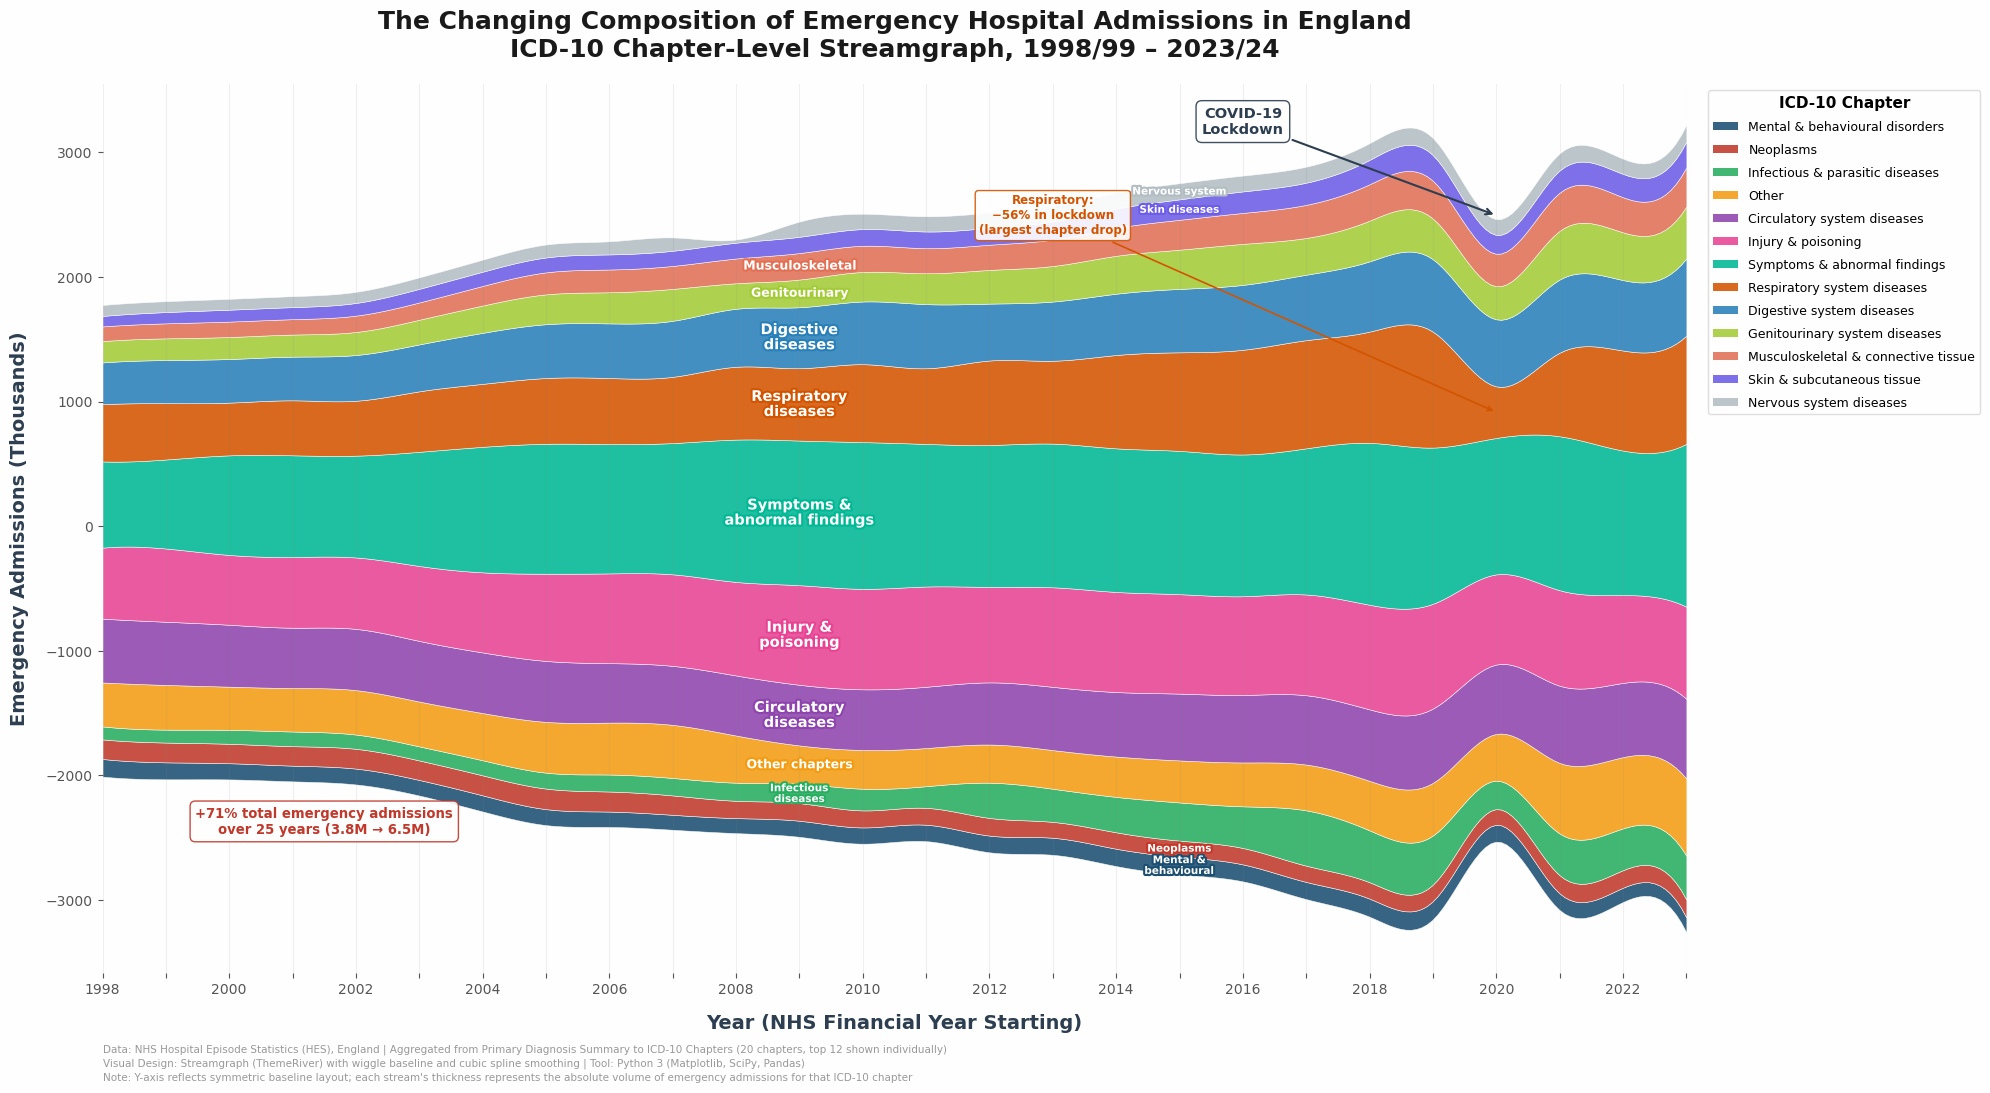


Image saved: streamgraph_final.png


In [8]:
# ---- Render the streamgraph ----

# Colour palette: Paletton-inspired, chosen for maximum contrast and aesthetics
COLORS = [
    '#1B4F72',  # Deep Navy         (Mental & behavioural)
    '#C0392B',  # Crimson           (Neoplasms)
    '#27AE60',  # Emerald           (Infectious diseases)
    '#F39C12',  # Sunflower         (Other)
    '#8E44AD',  # Wisteria          (Circulatory)
    '#E84393',  # Pink Glamour      (Injury & poisoning)
    '#00B894',  # Mint              (Symptoms & abnormal findings)
    '#D35400',  # Pumpkin           (Respiratory)
    '#2980B9',  # Belize Blue       (Digestive)
    '#A3CB38',  # Lime              (Genitourinary)
    '#E17055',  # Burnt Sienna      (Musculoskeletal)
    '#6C5CE7',  # Soft Purple       (Skin & subcutaneous)
    '#B2BEC3',  # Light Grey        (Other chapters)
]

# Short names for direct stream labels
SHORT_NAMES = {
    'Symptoms & abnormal findings':      'Symptoms &\nabnormal findings',
    'Injury & poisoning':                'Injury &\npoisoning',
    'Respiratory system diseases':       'Respiratory\ndiseases',
    'Circulatory system diseases':       'Circulatory\ndiseases',
    'Digestive system diseases':         'Digestive\ndiseases',
    'Genitourinary system diseases':     'Genitourinary',
    'Infectious & parasitic diseases':   'Infectious\ndiseases',
    'Musculoskeletal & connective tissue': 'Musculoskeletal',
    'Mental & behavioural disorders':    'Mental &\nbehavioural',
    'Skin & subcutaneous tissue':        'Skin diseases',
    'Neoplasms':                         'Neoplasms',
    'Nervous system diseases':           'Nervous system',
    'Other':                             'Other chapters',
}

fig, ax = plt.subplots(figsize=(20, 11))
fig.set_facecolor('#FEFEFE')
ax.set_facecolor('#FEFEFE')

# Draw each stream
for i in range(n_layers):
    ax.fill_between(years_smooth, bottoms[i], tops[i],
                     color=COLORS[i], alpha=0.88,
                     edgecolor='white', linewidth=0.4)

# ---- Direct labels on streams ----
for i in range(n_layers):
    ch_name = center_order[i]
    total = pivot_grouped[ch_name].sum()
    lx = 2009 if total > 4_000_000 else 2015  # larger streams labelled earlier
    
    x_idx = np.argmin(np.abs(years_smooth - lx))
    y_center = (bottoms[i][x_idx] + tops[i][x_idx]) / 2
    stream_height = tops[i][x_idx] - bottoms[i][x_idx]
    
    if stream_height > 50:  # only label streams thick enough to read
        label = SHORT_NAMES.get(ch_name, ch_name)
        fontsize = 6.5 if stream_height < 100 else (7.5 if stream_height < 200 else (9 if stream_height < 400 else 10.5))
        
        ax.text(lx, y_center, label, fontsize=fontsize,
                fontweight='bold', color='white', ha='center', va='center',
                linespacing=1.1,
                path_effects=[pe.withStroke(linewidth=3, foreground=COLORS[i])])

# ---- Annotations ----

# COVID-19 lockdown marker
covid_x_idx = np.argmin(np.abs(years_smooth - 2020))
covid_y_top = tops[-1][covid_x_idx]
ax.annotate('COVID-19\nLockdown',
            xy=(2020, covid_y_top + 30),
            xytext=(2016, tops.max() * 0.97),
            fontsize=10.5, fontweight='bold', color='#2C3E50',
            arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5),
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#2C3E50', alpha=0.9))

# Overall growth callout
ax.annotate('+71% total emergency admissions\nover 25 years (3.8M → 6.5M)',
            xy=(2023, (tops[-1][-1] + bottoms[0][-1]) / 2),
            xytext=(2001.5, bottoms[0][np.argmin(np.abs(years_smooth - 2001))] - 200),
            fontsize=9.5, fontweight='bold', color='#C0392B',
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#C0392B', alpha=0.9))

# Respiratory COVID drop callout
resp_idx = center_order.index('Respiratory system diseases')
resp_2020_x = np.argmin(np.abs(years_smooth - 2020))
resp_y = (bottoms[resp_idx][resp_2020_x] + tops[resp_idx][resp_2020_x]) / 2
ax.annotate('Respiratory:\n−56% in lockdown\n(largest chapter drop)',
            xy=(2020, resp_y),
            xytext=(2013, tops.max() * 0.72),
            fontsize=8.5, fontweight='bold', color='#D35400',
            arrowprops=dict(arrowstyle='->', color='#D35400', lw=1.2),
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#D35400', alpha=0.9))

# ---- Axes styling ----
ax.set_xlabel('Year (NHS Financial Year Starting)', fontsize=14,
              fontweight='bold', labelpad=12, color='#2C3E50')
ax.set_ylabel('Emergency Admissions (Thousands)', fontsize=14,
              fontweight='bold', labelpad=12, color='#2C3E50')
ax.set_title('The Changing Composition of Emergency Hospital Admissions in England\n'
             'ICD-10 Chapter-Level Streamgraph, 1998/99 – 2023/24',
             fontsize=18, fontweight='bold', pad=20, color='#1a1a1a')

ax.set_xlim(1998, 2023)
ax.set_xticks(range(1998, 2024, 1))
ax.set_xticklabels([str(y) if y % 2 == 0 else '' for y in range(1998, 2024)], fontsize=10)
ax.tick_params(labelsize=10, colors='#555555')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='x', alpha=0.12, color='#888888')

# Legend
handles = [plt.Rectangle((0, 0), 1, 1, fc=COLORS[i], alpha=0.88) for i in range(n_layers)]
legend = ax.legend(handles, center_order, loc='upper left', bbox_to_anchor=(1.01, 1),
                   fontsize=9, frameon=True, framealpha=0.95, edgecolor='#dddddd',
                   title='ICD-10 Chapter', title_fontsize=11, fancybox=True,
                   labelspacing=0.8)
legend.get_title().set_fontweight('bold')

# Source and method note
ax.text(0.0, -0.08,
        'Data: NHS Hospital Episode Statistics (HES), England | Aggregated from Primary Diagnosis Summary to ICD-10 Chapters (20 chapters, top 12 shown individually)\n'
        'Visual Design: Streamgraph (ThemeRiver) with wiggle baseline and cubic spline smoothing | Tool: Python 3 (Matplotlib, SciPy, Pandas)\n'
        "Note: Y-axis reflects symmetric baseline layout; each stream's thickness represents the absolute volume of emergency admissions for that ICD-10 chapter",
        transform=ax.transAxes, fontsize=7.5, color='#999999', va='top', linespacing=1.5)

plt.tight_layout()
plt.savefig('streamgraph_final.png', dpi=300, bbox_inches='tight',
            facecolor='#FEFEFE', edgecolor='none')
plt.show()
print("\nImage saved: streamgraph_final.png")

## 7. Key Statistics for the Unique Observation

These statistics support the unique observations visible in the streamgraph.


In [9]:
# Summary statistics for report writing
print("=" * 80)
print("KEY STATISTICS FOR UNIQUE OBSERVATION")
print("=" * 80)

print(f"\nTotal emergency admissions:")
print(f"  1998/99: {pivot.loc[1998].sum():>12,.0f}")
print(f"  2019/20: {pivot.loc[2019].sum():>12,.0f}")
print(f"  2020/21: {pivot.loc[2020].sum():>12,.0f}  (COVID lockdown year)")
print(f"  2023/24: {pivot.loc[2023].sum():>12,.0f}")
print(f"  25-year growth: +{((pivot.loc[2023].sum() / pivot.loc[1998].sum()) - 1) * 100:.0f}%")
print(f"  COVID drop:     {((pivot.loc[2020].sum() / pivot.loc[2019].sum()) - 1) * 100:+.0f}%")

print(f"\n{'Chapter':<45s} {'25yr Growth':>12s} {'COVID Drop':>12s}")
print("-" * 70)
for ch in chapter_totals.index:
    v98, v23 = pivot.loc[1998, ch], pivot.loc[2023, ch]
    v19, v20 = pivot.loc[2019, ch], pivot.loc[2020, ch]
    growth = ((v23 / v98) - 1) * 100 if v98 > 0 else 0
    covid = ((v20 / v19) - 1) * 100 if v19 > 0 else 0
    print(f"{ch:<45s} {growth:>+11.0f}% {covid:>+11.0f}%")

print("\n--- Top 3 fastest-growing chapters ---")
growth_rates = {}
for ch in chapter_totals.index:
    v98, v23 = pivot.loc[1998, ch], pivot.loc[2023, ch]
    if v98 > 0:
        growth_rates[ch] = ((v23 / v98) - 1) * 100
for ch, g in sorted(growth_rates.items(), key=lambda x: -x[1])[:3]:
    print(f"  {ch}: +{g:.0f}%")

print("\n--- 3 largest COVID drops ---")
covid_drops = {}
for ch in chapter_totals.index:
    v19, v20 = pivot.loc[2019, ch], pivot.loc[2020, ch]
    if v19 > 0:
        covid_drops[ch] = ((v20 / v19) - 1) * 100
for ch, d in sorted(covid_drops.items(), key=lambda x: x[1])[:3]:
    print(f"  {ch}: {d:+.0f}%")

KEY STATISTICS FOR UNIQUE OBSERVATION

Total emergency admissions:
  1998/99:    3,784,954
  2019/20:    6,268,789
  2020/21:    4,994,684  (COVID lockdown year)
  2023/24:    6,482,961
  25-year growth: +71%
  COVID drop:     -20%

Chapter                                        25yr Growth   COVID Drop
----------------------------------------------------------------------
Symptoms & abnormal findings                          +89%         -13%
Injury & poisoning                                    +30%         -14%
Respiratory system diseases                           +89%         -56%
Circulatory system diseases                           +25%          -7%
Digestive system diseases                             +85%          -7%
Genitourinary system diseases                        +144%         -18%
Infectious & parasitic diseases                      +237%         -42%
Musculoskeletal & connective tissue                  +167%         -14%
Neoplasms                                       